Original columns: ['Date', 'sentiment', 'sentiment_lag7', 'sentiment_lag14', 'sentiment_lag28', 'sentiment_rolling14']

News expert features created successfully.
Saved to: news_expert_features.csv

Shape of final dataset: (1190, 13)

First 5 rows:
        Date  sentiment  sentiment_lag7  sentiment_lag14  sentiment_lag28  \
0 2020-03-28   0.120403        1.745059        -2.102483        -0.614786   
1 2020-03-29   2.428848       -0.656531         0.618799        -1.071503   
2 2020-03-30  -0.572296       -1.598684        -0.907057         0.391375   
3 2020-03-31  -2.288667       -1.734251        -2.817000         0.357056   
4 2020-04-01   0.827010        0.198533         0.459581        -1.615299   

   sentiment_rolling14  news_risk_index  news_risk_lag7  news_risk_lag14  \
0            -1.812104        -0.120403       -1.745059         2.102483   
1            -1.411198        -2.428848        0.656531        -0.618799   
2            -1.333593         0.572296        1.598684     

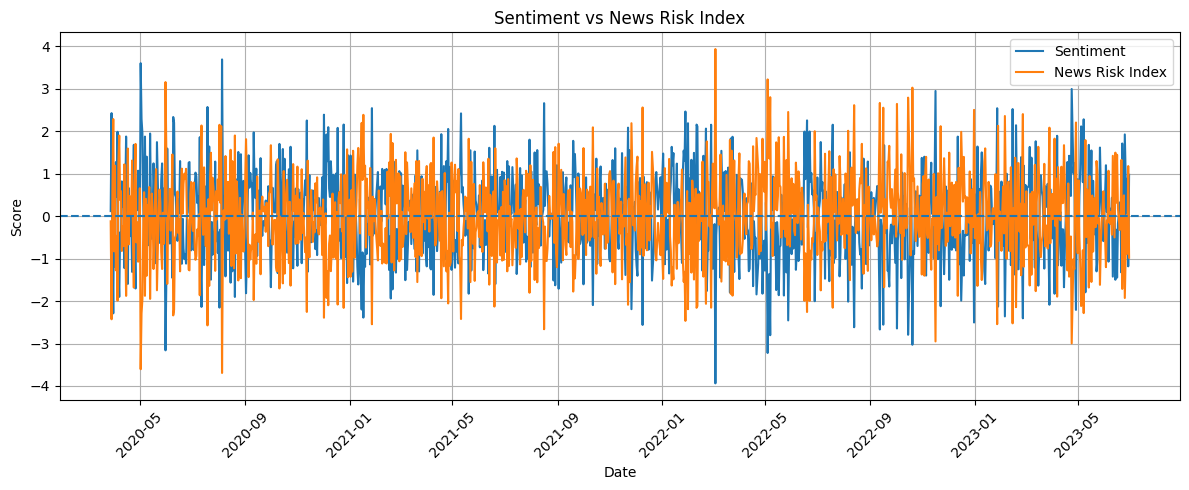

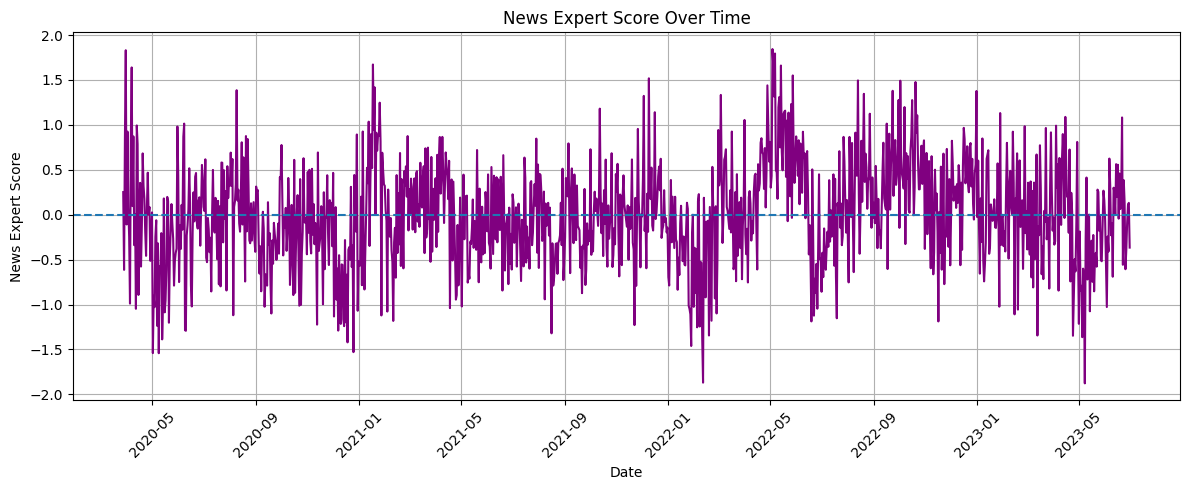

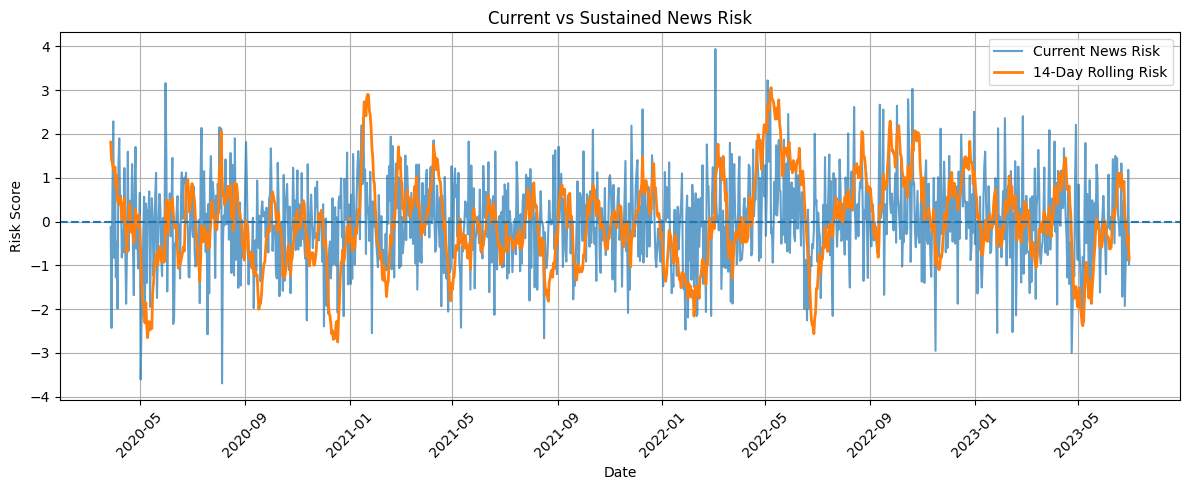

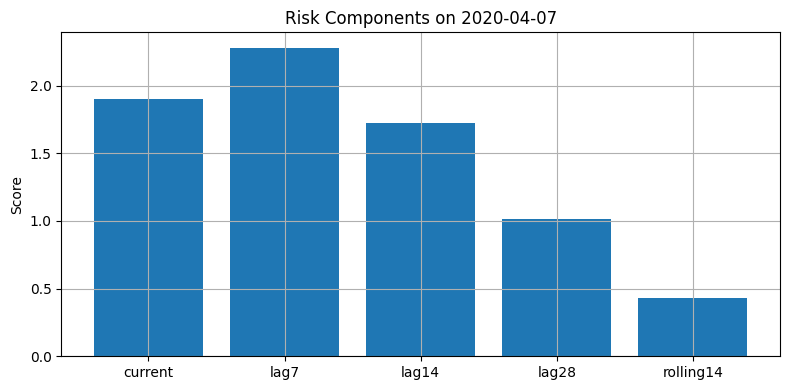


--- INTERPRETATION FOR ONE DATE ---
Date: 2020-04-07
Sentiment: -1.8994
News Risk Index: 1.8994
News Expert Score: 1.6393
Risk Label: High Risk
Interpretation: Strong news-driven disruption signal. This may support a high-risk or congested regime.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

INPUT_CSV = "maritime_news_preprocessed.csv"
OUTPUT_CSV = "news_expert_features.csv"

df = pd.read_csv(INPUT_CSV)
print("Original columns:", df.columns.tolist())

required_cols = [
    "Date",
    "sentiment",
    "sentiment_lag7",
    "sentiment_lag14",
    "sentiment_lag28",
    "sentiment_rolling14"
]

missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df = df.dropna(subset=["Date"])

df = df.sort_values("Date").reset_index(drop=True)

numeric_cols = [
    "sentiment",
    "sentiment_lag7",
    "sentiment_lag14",
    "sentiment_lag28",
    "sentiment_rolling14"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[numeric_cols] = df[numeric_cols].interpolate(method="linear", limit_direction="both")

df[numeric_cols] = df[numeric_cols].fillna(0)

df["news_risk_index"] = -df["sentiment"]
df["news_risk_lag7"] = -df["sentiment_lag7"]
df["news_risk_lag14"] = -df["sentiment_lag14"]
df["news_risk_lag28"] = -df["sentiment_lag28"]
df["news_risk_rolling14"] = -df["sentiment_rolling14"]

df["news_expert_score"] = (
    0.40 * df["news_risk_index"] +
    0.20 * df["news_risk_lag7"] +
    0.15 * df["news_risk_lag14"] +
    0.10 * df["news_risk_lag28"] +
    0.15 * df["news_risk_rolling14"]
)

df["news_expert_score"] = df["news_expert_score"].clip(lower=-5, upper=5)

def risk_label(score):
    if score > 1.0:
        return "High Risk"
    elif score > 0.2:
        return "Moderate Risk"
    else:
        return "Low Risk"

df["news_risk_label"] = df["news_expert_score"].apply(risk_label)

df.to_csv(OUTPUT_CSV, index=False)

print("\nNews expert features created successfully.")
print("Saved to:", OUTPUT_CSV)
print("\nShape of final dataset:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

print("\nFinal columns:")
print(df.columns.tolist())

summary_cols = [
    "sentiment",
    "news_risk_index",
    "news_expert_score"
]

print("\nSummary statistics:")
print(df[summary_cols].describe())

plt.figure()
plt.plot(df["Date"], df["sentiment"], label="Sentiment")
plt.plot(df["Date"], df["news_risk_index"], label="News Risk Index")
plt.axhline(0, linestyle="--")
plt.title("Sentiment vs News Risk Index")
plt.xlabel("Date")
plt.ylabel("Score")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(df["Date"], df["news_expert_score"], color="purple")
plt.axhline(0, linestyle="--")
plt.title("News Expert Score Over Time")
plt.xlabel("Date")
plt.ylabel("News Expert Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(df["Date"], df["news_risk_index"], label="Current News Risk", alpha=0.7)
plt.plot(df["Date"], df["news_risk_rolling14"], label="14-Day Rolling Risk", linewidth=2)
plt.axhline(0, linestyle="--")
plt.title("Current vs Sustained News Risk")
plt.xlabel("Date")
plt.ylabel("Risk Score")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


example_row = df.iloc[row_index]

components = {
    "current": example_row["news_risk_index"],
    "lag7": example_row["news_risk_lag7"],
    "lag14": example_row["news_risk_lag14"],
    "lag28": example_row["news_risk_lag28"],
    "rolling14": example_row["news_risk_rolling14"]
}

plt.figure(figsize=(8, 4))
plt.bar(components.keys(), components.values())
plt.title(f"Risk Components on {example_row['Date'].date()}")
plt.ylabel("Score")
plt.tight_layout()
plt.show()


def explain_row(row):
    print("\n--- INTERPRETATION FOR ONE DATE ---")
    print("Date:", row["Date"].date())
    print("Sentiment:", round(row["sentiment"], 4))
    print("News Risk Index:", round(row["news_risk_index"], 4))
    print("News Expert Score:", round(row["news_expert_score"], 4))
    print("Risk Label:", row["news_risk_label"])

    if row["news_expert_score"] > 1.0:
        print("Interpretation: Strong news-driven disruption signal. This may support a high-risk or congested regime.")
    elif row["news_expert_score"] > 0.2:
        print("Interpretation: Moderate disruption signal. Some caution is needed.")
    else:
        print("Interpretation: Low disruption signal. News environment is relatively calm or improving.")

# Explain the same example row
explain_row(example_row)